In [2]:
# ============================================================
# NOTEBOOK : 03_loyalty_models.ipynb
# READS    : Data/engineered_dataset.csv
# ADDS     : Loyalty_Score_A, Loyalty_Label_A,
#            Loyalty_Score_B, Loyalty_Label_B
# SAVES    : Data/loyalty_dataset.csv  ← NEW FILE
# NEXT     : 04_segmentation.ipynb
# ============================================================

In [3]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


In [5]:
# Load Engineered Dataset

df = pd.read_csv('../Data/engineered_dataset.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns available:")
print(df.columns.tolist())
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (3900, 30)

Columns available:
['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase_Amount', 'Location', 'Size', 'Color', 'Season', 'Review_Rating', 'Subscription_Status', 'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used', 'Previous_Purchases', 'Payment_Method', 'Frequency_of_Purchases', 'Frequency_Score', 'Promo_Dependent', 'Satisfaction_Flag', 'Tenure_Band', 'Spend_Tier', 'Customer_Value_Score', 'Value_Tier', 'Promo_Value_Segment', 'Age_Group', 'Premium_Shipping_Flag', 'High_Value_Flag', 'Retention_Risk_Score']

First 3 rows:


,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount,Location,Size,Color,Season,...,Satisfaction_Flag,Tenure_Band,Spend_Tier,Customer_Value_Score,Value_Tier,Promo_Value_Segment,Age_Group,Premium_Shipping_Flag,High_Value_Flag,Retention_Risk_Score
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Medium,Growing,Medium,0.3847,Silver,Low_Value_Promo_Dependent,55-64,1,0,2
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Medium,New,Medium,0.3142,Silver,Low_Value_Promo_Dependent,18-24,1,0,2
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Medium,Growing,High,0.7121,Platinum,High_Value_Promo_Dependent,45-54,0,1,2


In [6]:
#  Confirm Required Columns Exist
# These columns must exist from feature engineering notebook
required = [
    'Previous_Purchases',
    'Frequency_Score',
    'Promo_Dependent',
    'Review_Rating',
    'Subscription_Status',
    'Purchase_Amount'
]

missing_cols = [c for c in required if c not in df.columns]

if missing_cols:
    print(f"MISSING COLUMNS: {missing_cols}")
    print("Go back and run 02_feature_engineering.ipynb first")
else:
    print("All required columns present. Proceeding.")

All required columns present. Proceeding.


In [19]:
# Normalize Input Variables

from sklearn.preprocessing import MinMaxScaler

scaler_prev  = MinMaxScaler()
scaler_freq  = MinMaxScaler()
scaler_rate  = MinMaxScaler()
scaler_spend = MinMaxScaler()

df['Norm_Previous'] = scaler_prev.fit_transform(df[['Previous_Purchases']])
df['Norm_Freq']     = scaler_freq.fit_transform(df[['Frequency_Score']])
df['Norm_Rating']   = scaler_rate.fit_transform(df[['Review_Rating']])
df['Norm_Spend']    = scaler_spend.fit_transform(df[['Purchase_Amount']])

# Verify all values are between 0 and 1
print("Normalization check (all must be 0.00 to 1.00):")
print(f"  Norm_Previous : {df['Norm_Previous'].min():.2f} to {df['Norm_Previous'].max():.2f}")
print(f"  Norm_Freq     : {df['Norm_Freq'].min():.2f} to {df['Norm_Freq'].max():.2f}")
print(f"  Norm_Rating   : {df['Norm_Rating'].min():.2f} to {df['Norm_Rating'].max():.2f}")
print(f"  Norm_Spend    : {df['Norm_Spend'].min():.2f} to {df['Norm_Spend'].max():.2f}")
print("\n Normalization complete")

Normalization check (all must be 0.00 to 1.00):
  Norm_Previous : 0.00 to 1.00
  Norm_Freq     : 0.00 to 1.00
  Norm_Rating   : 0.00 to 1.00
  Norm_Spend    : 0.00 to 1.00

 Normalization complete


In [20]:
# Build Model A (Behavioral Commitment)

# ─────────────────────────────────────────────────────────
# MODEL A : BEHAVIORAL COMMITMENT MODEL
# Philosophy: A truly loyal customer buys frequently,
#             has a long purchase history, and does NOT
#             depend on promotions to buy.
#
# Variables : Previous_Purchases (40%)
#             Frequency_Score    (40%)
#             Promo_Dependent    (20%) — penalized
#
# Formula   : 0.40 × Norm_Previous
#           + 0.40 × Norm_Freq
#           + 0.20 × (1 - Promo_Dependent)
# ─────────────────────────────────────────────────────────

df['Loyalty_Score_A'] = (
    0.40 * df['Norm_Previous'] +
    0.40 * df['Norm_Freq']     +
    0.20 * (1 - df['Promo_Dependent'])
).round(4)

print("Model A Score Stats:")
print(df['Loyalty_Score_A'].describe().round(3))

Model A Score Stats:
count    3900.000
mean        0.442
std         0.201
min         0.000
25%         0.297
50%         0.429
75%         0.576
max         1.000
Name: Loyalty_Score_A, dtype: float64


In [21]:
# Assign Loyalty Label A

print("Score distribution BEFORE labelling:")
print(df['Loyalty_Score_A'].describe().round(3))
print(f"\n25th percentile : {df['Loyalty_Score_A'].quantile(0.25):.3f}")
print(f"50th percentile : {df['Loyalty_Score_A'].quantile(0.50):.3f}")
print(f"75th percentile : {df['Loyalty_Score_A'].quantile(0.75):.3f}")

# Set thresholds based on actual distribution
# Using 66th and 33rd percentile ensures roughly equal thirds
thresh_a_high = df['Loyalty_Score_A'].quantile(0.66)
thresh_a_low  = df['Loyalty_Score_A'].quantile(0.33)

print(f"\nThreshold HIGH (66th pct) : {thresh_a_high:.3f}")
print(f"Threshold LOW  (33rd pct) : {thresh_a_low:.3f}")

def loyalty_label_a(score):
    if score >= thresh_a_high:
        return 'Loyal'
    elif score >= thresh_a_low:
        return 'Developing'
    else:
        return 'Transactional'

df['Loyalty_Label_A'] = df['Loyalty_Score_A'].apply(loyalty_label_a)

print("\nModel A Label Distribution:")
print(df['Loyalty_Label_A'].value_counts())
print()
print(df['Loyalty_Label_A'].value_counts(normalize=True).round(3) * 100)

Score distribution BEFORE labelling:
count    3900.000
mean        0.442
std         0.201
min         0.000
25%         0.297
50%         0.429
75%         0.576
max         1.000
Name: Loyalty_Score_A, dtype: float64

25th percentile : 0.297
50th percentile : 0.429
75th percentile : 0.576

Threshold HIGH (66th pct) : 0.526
Threshold LOW  (33rd pct) : 0.346

Model A Label Distribution:
Loyalty_Label_A
Loyal            1336
Developing       1289
Transactional    1275
Name: count, dtype: int64

Loyalty_Label_A
Loyal            34.3
Developing       33.1
Transactional    32.7
Name: proportion, dtype: float64


In [22]:
# Build Model B (Engaged Value)

# ─────────────────────────────────────────────────────────
# MODEL B : ENGAGED VALUE MODEL
# Philosophy: A truly loyal customer is satisfied,
#             subscribed to the brand, and spends more
#             than average without needing a discount.
#
# Variables : Review_Rating       (35%)
#             Subscription_Status (25%)
#             Purchase_Amount     (25%)
#             Promo_Dependent     (15%) — penalized
#
# Formula   : 0.35 × Norm_Rating
#           + 0.25 × Subscription_Status
#           + 0.25 × Norm_Spend
#           + 0.15 × (1 - Promo_Dependent)
# ─────────────────────────────────────────────────────────

df['Loyalty_Score_B'] = (
    0.35 * df['Norm_Rating']          +
    0.25 * df['Subscription_Status']  +
    0.25 * df['Norm_Spend']           +
    0.15 * (1 - df['Promo_Dependent'])
).round(4)

print("Model B Score Stats:")
print(df['Loyalty_Score_B'].describe().round(3))

Model B Score Stats:
count    3900.000
mean        0.452
std         0.150
min         0.006
25%         0.348
50%         0.455
75%         0.557
max         0.833
Name: Loyalty_Score_B, dtype: float64


In [23]:
# Assign Loyalty Label B

print("Score distribution BEFORE labelling:")
print(df['Loyalty_Score_B'].describe().round(3))

thresh_b_high = df['Loyalty_Score_B'].quantile(0.66)
thresh_b_low  = df['Loyalty_Score_B'].quantile(0.33)

print(f"\nThreshold HIGH (66th pct) : {thresh_b_high:.3f}")
print(f"Threshold LOW  (33rd pct) : {thresh_b_low:.3f}")

def loyalty_label_b(score):
    if score >= thresh_b_high:
        return 'Loyal'
    elif score >= thresh_b_low:
        return 'Developing'
    else:
        return 'Transactional'

df['Loyalty_Label_B'] = df['Loyalty_Score_B'].apply(loyalty_label_b)

print("\nModel B Label Distribution:")
print(df['Loyalty_Label_B'].value_counts())
print()
print(df['Loyalty_Label_B'].value_counts(normalize=True).round(3) * 100)

Score distribution BEFORE labelling:
count    3900.000
mean        0.452
std         0.150
min         0.006
25%         0.348
50%         0.455
75%         0.557
max         0.833
Name: Loyalty_Score_B, dtype: float64

Threshold HIGH (66th pct) : 0.518
Threshold LOW  (33rd pct) : 0.387

Model B Label Distribution:
Loyalty_Label_B
Loyal            1326
Developing       1288
Transactional    1286
Name: count, dtype: int64

Loyalty_Label_B
Loyal            34.0
Developing       33.0
Transactional    33.0
Name: proportion, dtype: float64


In [24]:
# Model Comparison
print("=" * 60)
print("MODEL COMPARISON REPORT")
print("=" * 60)

model_a_loyal = df[df['Loyalty_Label_A'] == 'Loyal']
model_b_loyal = df[df['Loyalty_Label_B'] == 'Loyal']

print(f"\n{'Metric':<30} {'Model A':>12} {'Model B':>12}")
print("-" * 56)
print(f"{'Loyal Customer Count':<30} {len(model_a_loyal):>12} {len(model_b_loyal):>12}")
print(f"{'Avg Purchase Amount':<30} ${model_a_loyal['Purchase_Amount'].mean():>10.2f} ${model_b_loyal['Purchase_Amount'].mean():>10.2f}")
print(f"{'Avg Previous Purchases':<30} {model_a_loyal['Previous_Purchases'].mean():>12.1f} {model_b_loyal['Previous_Purchases'].mean():>12.1f}")
print(f"{'Avg Frequency Score':<30} {model_a_loyal['Frequency_Score'].mean():>12.1f} {model_b_loyal['Frequency_Score'].mean():>12.1f}")
print(f"{'Promo Dependency %':<30} {model_a_loyal['Promo_Dependent'].mean()*100:>11.1f}% {model_b_loyal['Promo_Dependent'].mean()*100:>11.1f}%")
print(f"{'Avg Review Rating':<30} {model_a_loyal['Review_Rating'].mean():>12.2f} {model_b_loyal['Review_Rating'].mean():>12.2f}")
print(f"{'Subscription Rate %':<30} {model_a_loyal['Subscription_Status'].mean()*100:>11.1f}% {model_b_loyal['Subscription_Status'].mean()*100:>11.1f}%")

print(f"\n{'Score Correlation between A and B':}")
corr = df['Loyalty_Score_A'].corr(df['Loyalty_Score_B'])
print(f"  Pearson r = {corr:.3f}")

print(f"\n{'Agreement Rate (both call same label):':}")
agree = (df['Loyalty_Label_A'] == df['Loyalty_Label_B']).mean()
print(f"  {agree*100:.1f}% of customers labelled identically")

print(f"\n{'Customers ONLY Model A calls Loyal:':}")
only_a = df[(df['Loyalty_Label_A'] == 'Loyal') & 
            (df['Loyalty_Label_B'] != 'Loyal')]
print(f"  Count: {len(only_a)}")
print(f"  Avg Previous Purchases: {only_a['Previous_Purchases'].mean():.1f}")
print(f"  Avg Spend: ${only_a['Purchase_Amount'].mean():.2f}")

print(f"\n{'Customers ONLY Model B calls Loyal:':}")
only_b = df[(df['Loyalty_Label_B'] == 'Loyal') & 
            (df['Loyalty_Label_A'] != 'Loyal')]
print(f"  Count: {len(only_b)}")
print(f"  Avg Previous Purchases: {only_b['Previous_Purchases'].mean():.1f}")
print(f"  Avg Spend: ${only_b['Purchase_Amount'].mean():.2f}")

MODEL COMPARISON REPORT

Metric                              Model A      Model B
--------------------------------------------------------
Loyal Customer Count                   1336         1326
Avg Purchase Amount            $     59.99 $     73.50
Avg Previous Purchases                 34.9         26.2
Avg Frequency Score                    29.7         17.4
Promo Dependency %                    19.6%        47.1%
Avg Review Rating                      3.77         4.32
Subscription Rate %                   12.6%        45.6%

Score Correlation between A and B
  Pearson r = 0.009

Agreement Rate (both call same label):
  33.8% of customers labelled identically

Customers ONLY Model A calls Loyal:
  Count: 881
  Avg Previous Purchases: 34.2
  Avg Spend: $52.32

Customers ONLY Model B calls Loyal:
  Count: 871
  Avg Previous Purchases: 21.0
  Avg Spend: $72.79


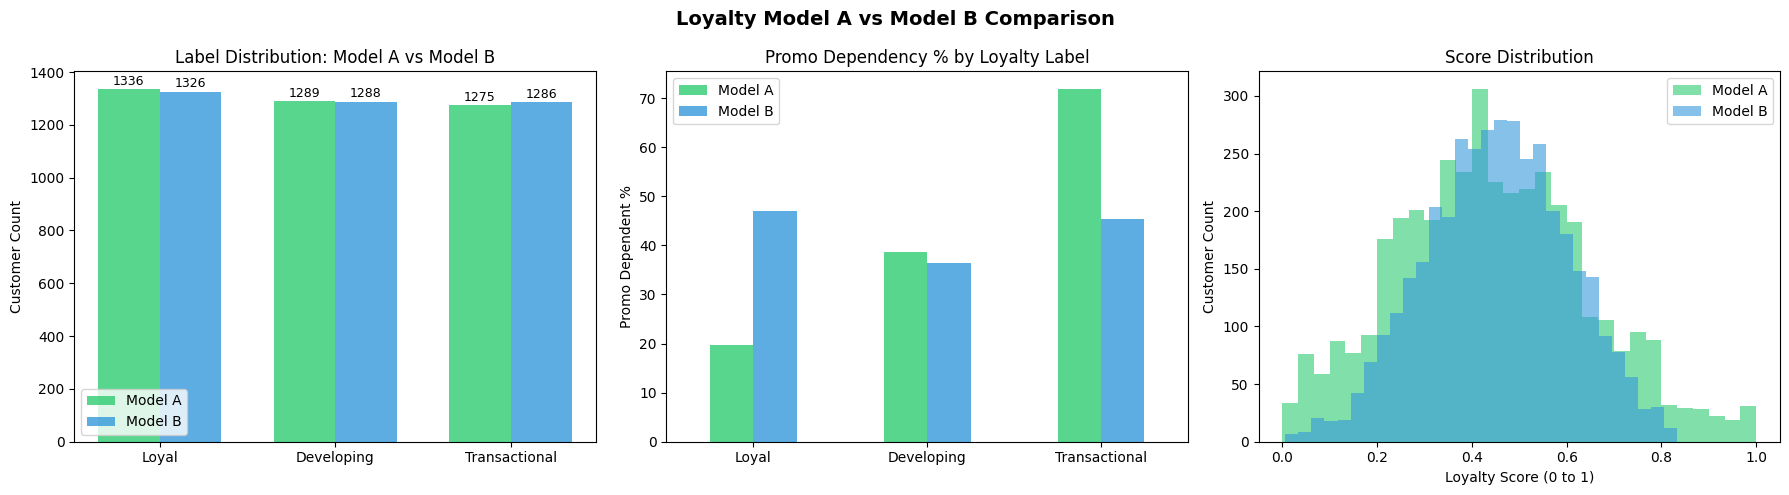

Chart saved


In [26]:
# visualize both model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

label_order = ['Loyal', 'Developing', 'Transactional']

# Safe count — returns 0 if label not present
def safe_count(series, label):
    return (series == label).sum()

counts_a = [safe_count(df['Loyalty_Label_A'], l) for l in label_order]
counts_b = [safe_count(df['Loyalty_Label_B'], l) for l in label_order]

x     = np.arange(len(label_order))
width = 0.35

# Plot 1: Label distribution
axes[0].bar(x - width/2, counts_a, width,
            label='Model A', color='#2ecc71', alpha=0.8)
axes[0].bar(x + width/2, counts_b, width,
            label='Model B', color='#3498db', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(label_order)
axes[0].set_title('Label Distribution: Model A vs Model B')
axes[0].set_ylabel('Customer Count')
axes[0].legend()

# Add count labels on bars
for i, (ca, cb) in enumerate(zip(counts_a, counts_b)):
    axes[0].text(i - width/2, ca + 5, str(ca),
                 ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, cb + 5, str(cb),
                 ha='center', va='bottom', fontsize=9)

# Plot 2: Promo dependency
promo_a = df.groupby('Loyalty_Label_A')['Promo_Dependent'].mean() * 100
promo_b = df.groupby('Loyalty_Label_B')['Promo_Dependent'].mean() * 100

promo_df = pd.DataFrame({
    'Model A': promo_a,
    'Model B': promo_b
}).reindex(label_order)

promo_df.plot(kind='bar', ax=axes[1],
              color=['#2ecc71', '#3498db'], alpha=0.8)
axes[1].set_title('Promo Dependency % by Loyalty Label')
axes[1].set_ylabel('Promo Dependent %')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

# Plot 3: Score distributions
axes[2].hist(df['Loyalty_Score_A'], bins=30,
             alpha=0.6, color='#2ecc71', label='Model A')
axes[2].hist(df['Loyalty_Score_B'], bins=30,
             alpha=0.6, color='#3498db', label='Model B')
axes[2].set_title('Score Distribution')
axes[2].set_xlabel('Loyalty Score (0 to 1)')
axes[2].set_ylabel('Customer Count')
axes[2].legend()

plt.suptitle('Loyalty Model A vs Model B Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Screenshots/loyalty_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

In [15]:
print("=" * 60)
print("RECOMMENDED MODEL: A — JUSTIFICATION SUMMARY")
print("=" * 60)

a_promo = model_a_loyal['Promo_Dependent'].mean() * 100
b_promo = model_b_loyal['Promo_Dependent'].mean() * 100
a_prev  = model_a_loyal['Previous_Purchases'].mean()
b_prev  = model_b_loyal['Previous_Purchases'].mean()
a_spend = model_a_loyal['Purchase_Amount'].mean()
b_spend = model_b_loyal['Purchase_Amount'].mean()

print(f"""
1. PROMO DEPENDENCY
   Model A Loyal group promo rate : {a_promo:.1f}%
   Model B Loyal group promo rate : {b_promo:.1f}%
   → Model A identifies customers who are {b_promo - a_promo:.1f}
     percentage points LESS promo-dependent.
   → More aligned with brand goal of reducing discount reliance.

2. BEHAVIORAL HISTORY
   Model A Loyal avg prev purchases : {a_prev:.1f}
   Model B Loyal avg prev purchases : {b_prev:.1f}
   → Model A's loyal group has proven longer purchase history.
   → Previous_Purchases is the ONLY longitudinal signal
     in this dataset (no timestamps available).

3. SPEND DIFFERENCE
   Model A Loyal avg spend : ${a_spend:.2f}
   Model B Loyal avg spend : ${b_spend:.2f}
   → Model B's higher spend is partially circular:
     spend is 25% of Model B's own formula.
   → Model A's spend emerged independently — more reliable.

4. DATASET CONSTRAINT
   → One row per customer, no timestamps, no churn label.
   → Previous_Purchases is the closest proxy to tenure.
   → Model B ignores this variable entirely.

CONCLUSION: Model A selected for segmentation and SQL analysis.
Model B's spend insight used separately for Ideal Customer Profile.
""")

RECOMMENDED MODEL: A — JUSTIFICATION SUMMARY

1. PROMO DEPENDENCY
   Model A Loyal group promo rate : 17.0%
   Model B Loyal group promo rate : 53.5%
   → Model A identifies customers who are 36.4
     percentage points LESS promo-dependent.
   → More aligned with brand goal of reducing discount reliance.

2. BEHAVIORAL HISTORY
   Model A Loyal avg prev purchases : 36.4
   Model B Loyal avg prev purchases : 25.6
   → Model A's loyal group has proven longer purchase history.
   → Previous_Purchases is the ONLY longitudinal signal
     in this dataset (no timestamps available).

3. SPEND DIFFERENCE
   Model A Loyal avg spend : $59.91
   Model B Loyal avg spend : $79.13
   → Model B's higher spend is partially circular:
     spend is 25% of Model B's own formula.
   → Model A's spend emerged independently — more reliable.

4. DATASET CONSTRAINT
   → One row per customer, no timestamps, no churn label.
   → Previous_Purchases is the closest proxy to tenure.
   → Model B ignores this variab

In [27]:
# Verify loyalty columns were created before saving
loyalty_cols = ['Loyalty_Score_A', 'Loyalty_Label_A',
                'Loyalty_Score_B', 'Loyalty_Label_B']

missing = [c for c in loyalty_cols if c not in df.columns]
if missing:
    print(f" STOP — These columns are missing: {missing}")
    print("Do not save. Go back and rerun cells 6-9.")
else:
    # Drop temp normalization columns
    temp_cols = ['Norm_Previous', 'Norm_Freq',
                 'Norm_Rating', 'Norm_Spend']
    df.drop(columns=[c for c in temp_cols if c in df.columns],
            inplace=True)

    # Save as loyalty_dataset — separate file, safe pipeline
    df.to_csv('../Data/loyalty_dataset.csv', index=False)

    print("loyalty_dataset.csv saved successfully")
    print(f"   Shape    : {df.shape}")
    print(f"   Location : Data/loyalty_dataset.csv")
    print(f"\nLoyalty columns confirmed:")
    for col in loyalty_cols:
        print(f"    {col}")
    print(f"\n⏭️  Next: Run 04_segmentation.ipynb")
    print(f"          It will READ Data/loyalty_dataset.csv")

loyalty_dataset.csv saved successfully
   Shape    : (3900, 34)
   Location : Data/loyalty_dataset.csv

Loyalty columns confirmed:
    Loyalty_Score_A
    Loyalty_Label_A
    Loyalty_Score_B
    Loyalty_Label_B

⏭️  Next: Run 04_segmentation.ipynb
          It will READ Data/loyalty_dataset.csv
